# Entrega 2 — Comparacao de Abordagens de Visao Computacional

**Aluno:** Diogo Pereira  
**RM:** 568326  
**Disciplina:** PBL - Fase 6  
**FarmTech Solutions** - Sistema de Visao Computacional

---

## Objetivo

Comparar tres abordagens de visao computacional aplicadas ao mesmo dataset de macas e garrafas:

1. **YOLO Customizada (Entrega 1):** YOLOv5 fine-tuned com 30 e 60 epocas no dataset customizado.
2. **YOLO Padrao (Pre-treinada):** YOLOv5 pre-treinada no COCO, sem fine-tuning, aplicada diretamente nas imagens de teste.
3. **CNN Treinada do Zero:** Rede convolucional construida e treinada do zero para classificacao binaria (maca vs garrafa).

A avaliacao sera feita em termos de: facilidade de uso, precisao, tempo de treinamento e tempo de inferencia.

## 1. Configuracao do Ambiente

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!git clone https://github.com/ultralytics/yolov5
%cd yolov5
!pip install -r requirements.txt

Cloning into 'yolov5'...
remote: Enumerating objects: 17898, done.
remote: Counting objects: 100% (58/58), done.
remote: Compressing objects: 100% (47/47), done.
remote: Total 17898 (delta 38), reused 12 (delta 11), pack-reused 17840 (from 5)
Receiving objects: 100% (17898/17898), 17.05 MiB | 23.82 MiB/s, done.
Resolving deltas: 100% (12185/12185), done.
/content/yolov5
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.6/131.6 kB 11.1 MB/s eta 0:00:00
  Attempting uninstall: urllib3
    Found existing installation: urllib3 2.5.0
    Uninstalling urllib3-2.5.0:
      Successfully uninstalled urllib3-2.5.0


In [3]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display, Image as IPImage

DRIVE_DATASET = '/content/drive/MyDrive/dataset_yolo'

---
## 2. Abordagem 1 — YOLO Padrao (Pre-treinada no COCO, sem fine-tuning)

Nesta abordagem, utilizamos o modelo YOLOv5s pre-treinado no dataset COCO (80 classes) **sem nenhum fine-tuning**. O COCO ja possui as classes `apple` (classe 47) e `bottle` (classe 39), entao o modelo consegue detectar esses objetos diretamente.

O objetivo e avaliar se um modelo generico, sem customizacao, consegue lidar bem com as nossas imagens.

In [4]:
print('=== Deteccao com YOLO Padrao (Pre-treinada COCO) ===')
print('Executando inferencia nas imagens de teste...\n')

start_time = time.time()
!python detect.py --weights yolov5s.pt --source '{DRIVE_DATASET}/test/images' --img 640 --conf 0.25 --name yolo_padrao_test --save-txt --save-conf
yolo_padrao_inference_time = time.time() - start_time
print(f'\nTempo total de inferencia (YOLO Padrao): {yolo_padrao_inference_time:.2f}s')

=== Deteccao com YOLO Padrao (Pre-treinada COCO) ===
Executando inferencia nas imagens de teste...

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
detect: weights=['yolov5s.pt'], source=/content/drive/MyDrive/dataset_yolo/test/images, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=True, save_format=0, save_csv=False, save_conf=True, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=yolo_padrao_test, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-478-g6c66ecd5 Python-3.12.13 torch-2.10.0+cpu CPU


In [5]:
print('=== Deteccao YOLO Padrao nas imagens de VALIDACAO ===')
!python detect.py --weights yolov5s.pt --source '{DRIVE_DATASET}/val/images' --img 640 --conf 0.25 --name yolo_padrao_val --save-txt --save-conf

=== Deteccao YOLO Padrao nas imagens de VALIDACAO ===
detect: weights=['yolov5s.pt'], source=/content/drive/MyDrive/dataset_yolo/val/images, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=True, save_format=0, save_csv=False, save_conf=True, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=yolo_padrao_val, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-478-g6c66ecd5 Python-3.12.13 torch-2.10.0+cpu CPU

Fusing layers... 
YOLOv5s summary: 213 layers, 7225885 parameters, 0 gradients, 16.4 GFLOPs
image 1/8 /content/drive/MyDrive/dataset_yolo/val/images/garrafa_032.jpg: 448x640 1 bottle, 2 vases, 303.4ms
image 2/8 /content/drive/MyDrive/dataset_yolo/val/images/garrafa_033.jpg: 448x640 1 scissors, 469.7ms
image 3/8 /content/drive/MyDrive/dataset_yolo/val/image

### 2.1 Visualizacao dos Resultados — YOLO Padrao

  RESULTADOS - YOLO PADRAO (COCO)

garrafa_036.jpeg


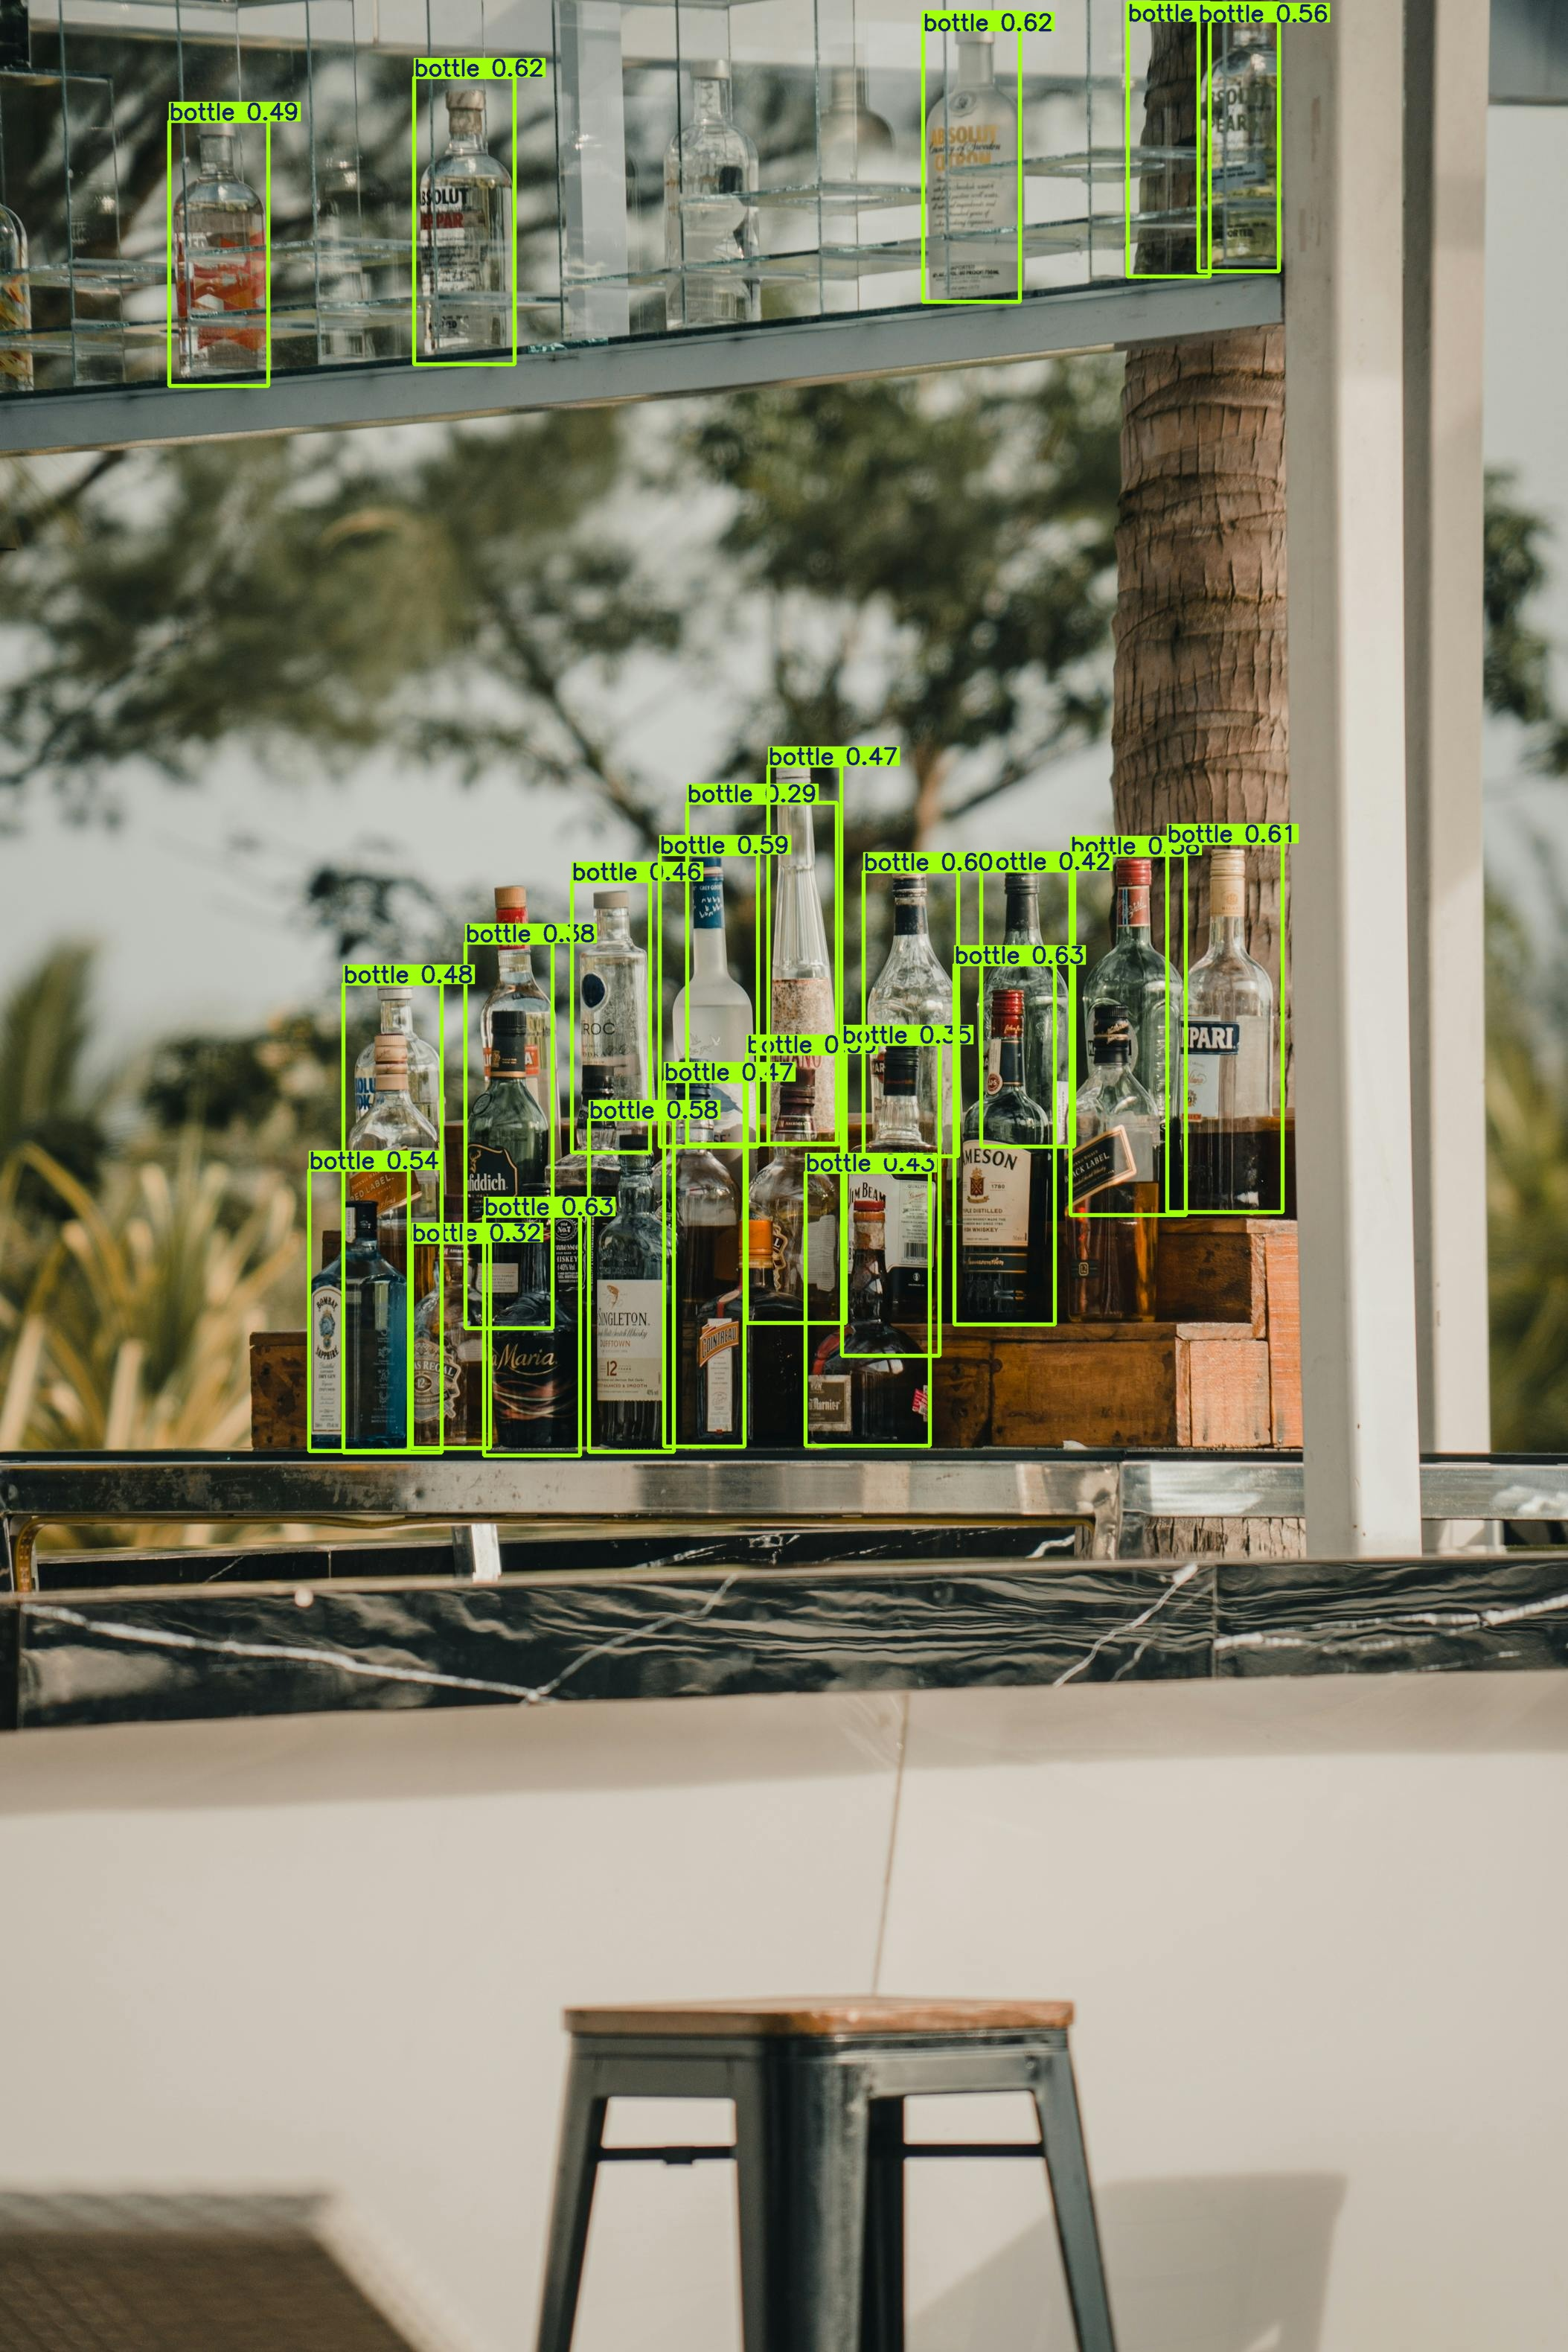


garrafa_037.jpg


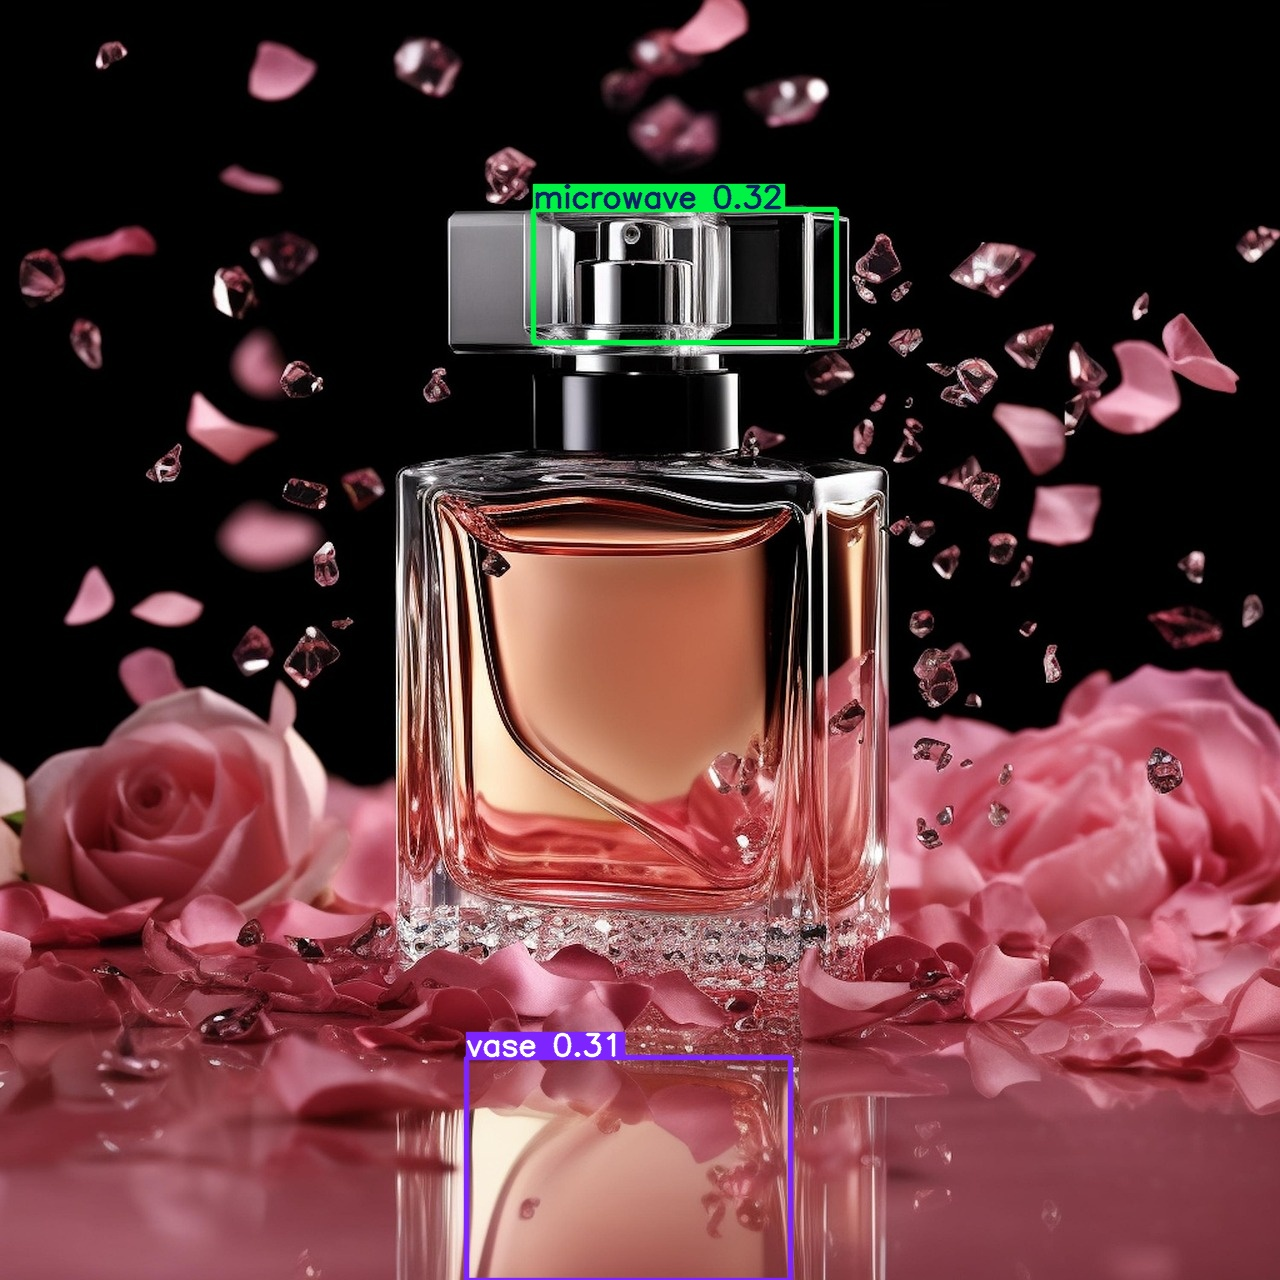


garrafa_038.jpg


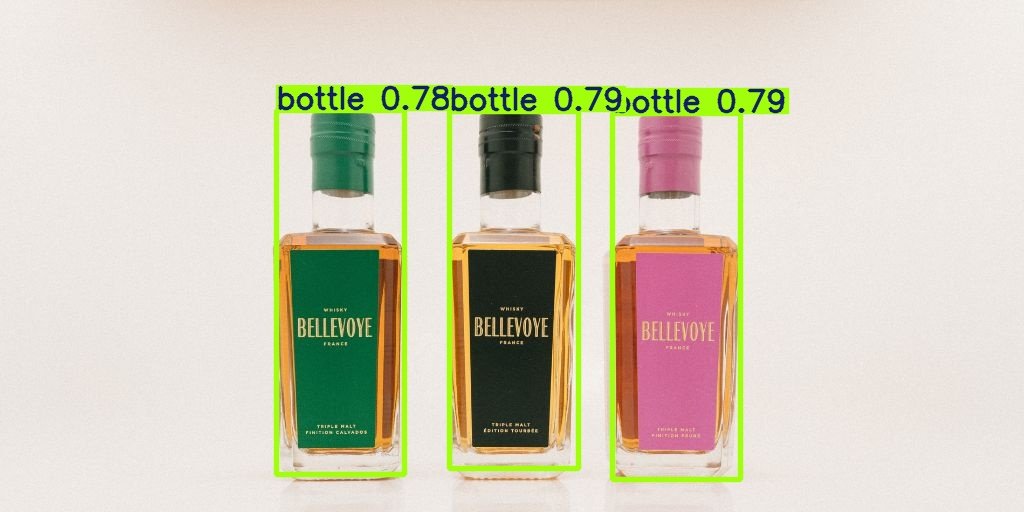


garrafa_039.jpg


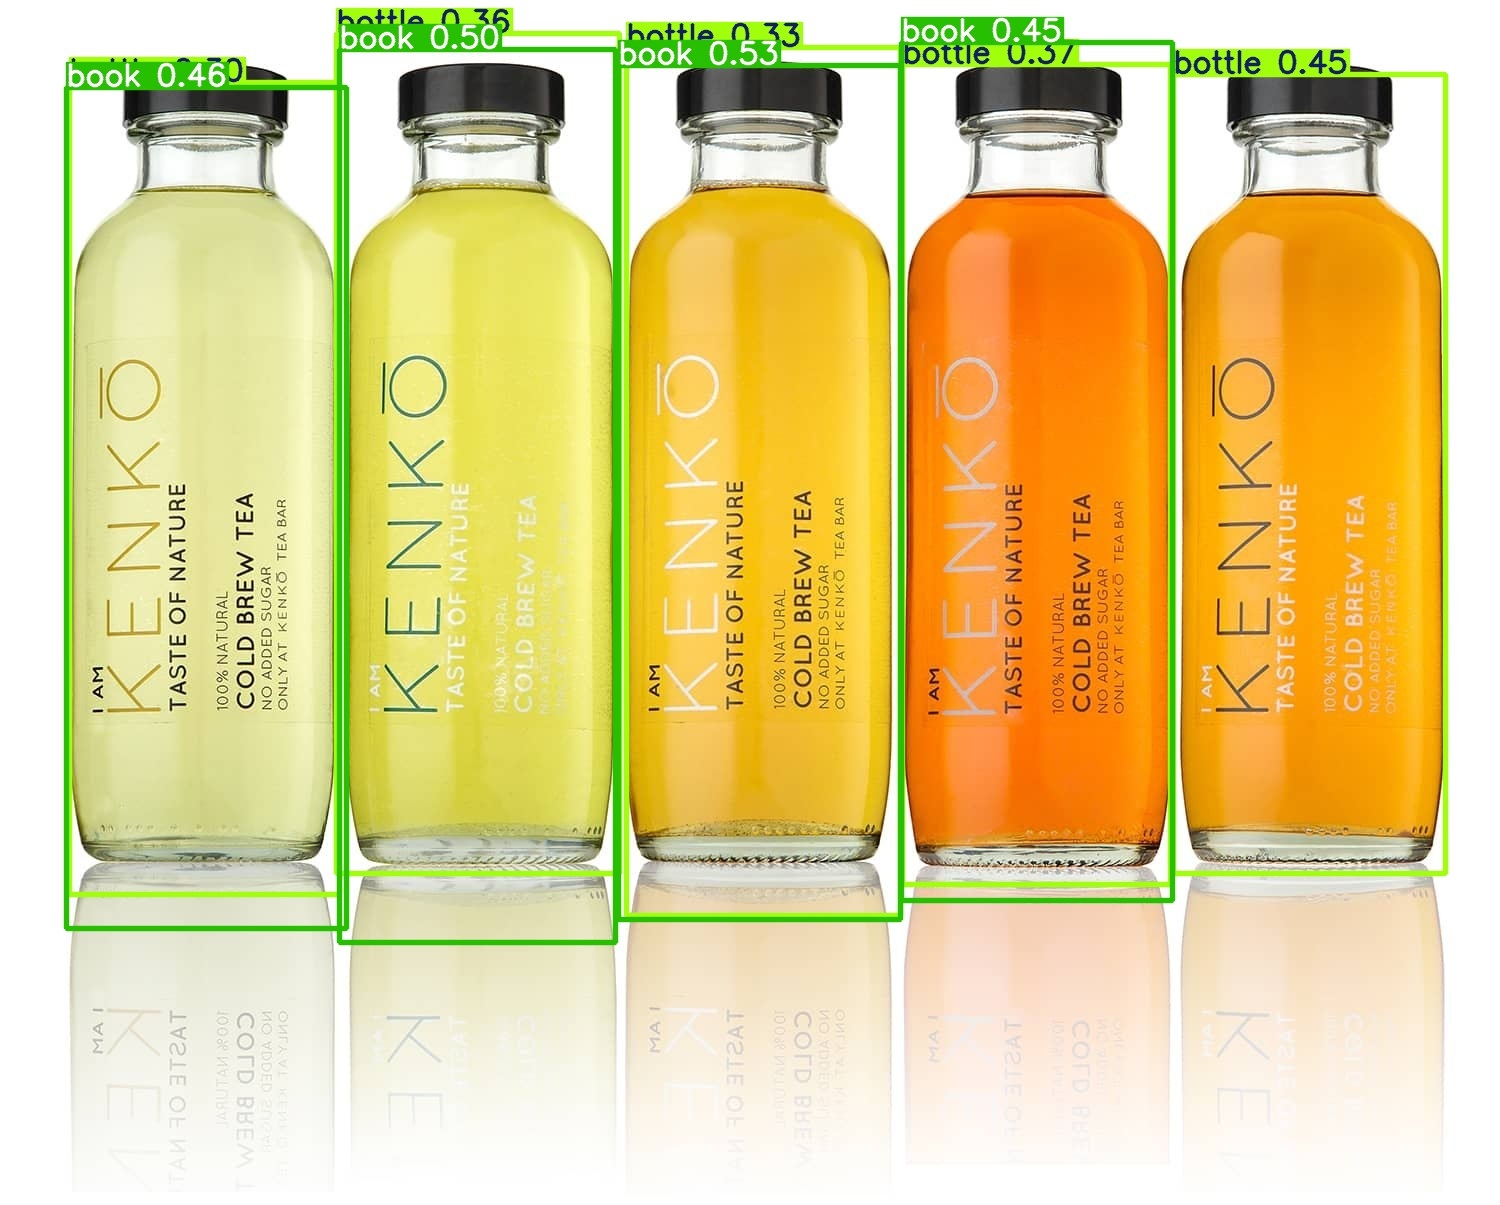


maca_036.jpg


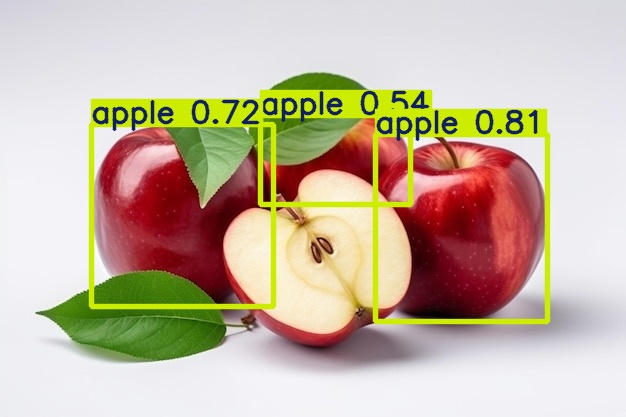


maca_037.jpg


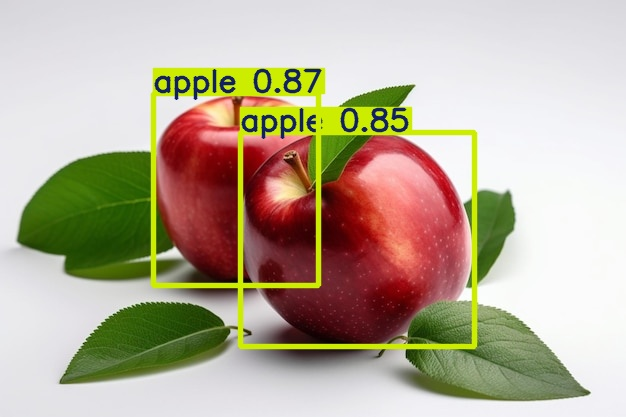


maca_038.jpg


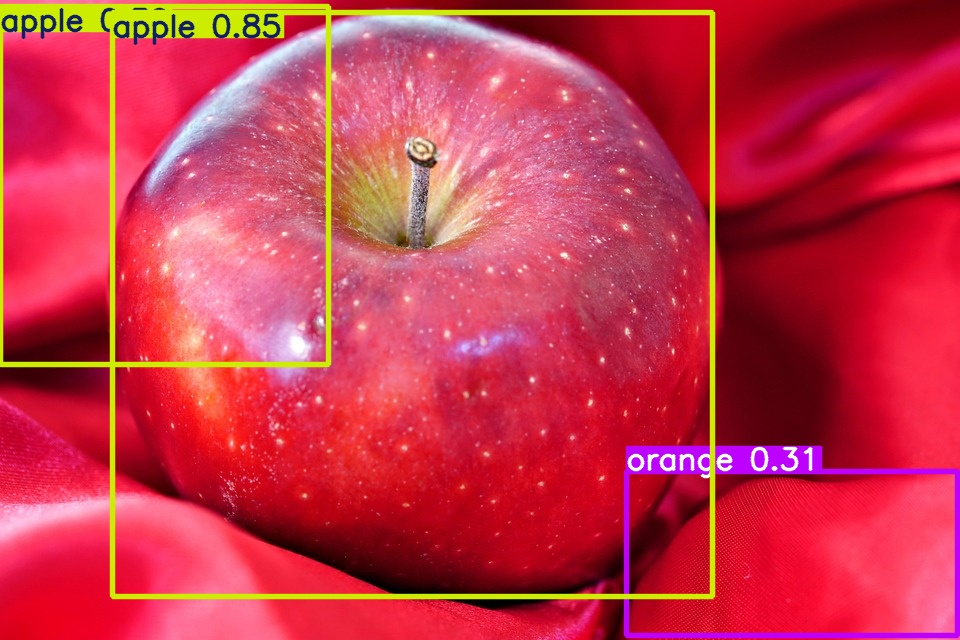


maca_039.jpg


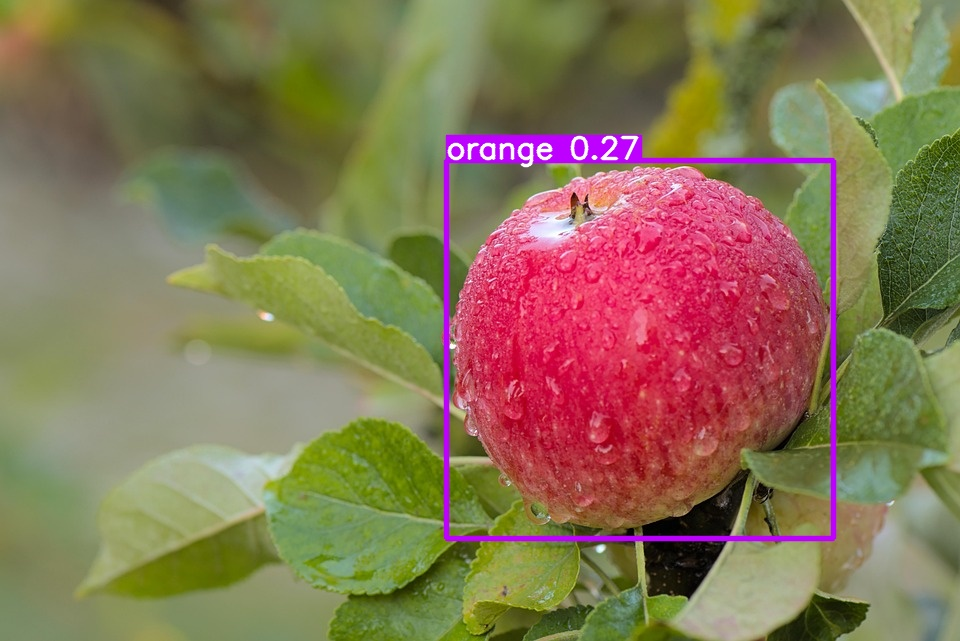

In [6]:
import glob

print('=========================================')
print('  RESULTADOS - YOLO PADRAO (COCO)')
print('=========================================')
test_imgs = sorted(glob.glob('runs/detect/yolo_padrao_test/*.jpg') + glob.glob('runs/detect/yolo_padrao_test/*.jpeg') + glob.glob('runs/detect/yolo_padrao_test/*.png'))
for img_path in test_imgs:
    print(f'\n{os.path.basename(img_path)}')
    display(IPImage(filename=img_path, width=500))

### 2.2 Analise Quantitativa — YOLO Padrao

Vamos calcular quantas imagens de teste foram corretamente detectadas pelo modelo padrao. Como o COCO usa nomes em ingles (`apple` = 47, `bottle` = 39), mapeamos para nossas classes.

In [7]:
import os

COCO_APPLE = 47
COCO_BOTTLE = 39

label_dir = 'runs/detect/yolo_padrao_test/labels'
test_images_dir = f'{DRIVE_DATASET}/test/images'

correct = 0
total = 0
results_padrao = []

for img_file in sorted(os.listdir(test_images_dir)):
    if not img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
        continue
    total += 1
    name = os.path.splitext(img_file)[0]
    true_class = 'maca' if name.startswith('maca') else 'garrafa'

    label_file = os.path.join(label_dir, name + '.txt')
    detected_class = 'nenhuma'
    confidence = 0.0

    if os.path.exists(label_file):
        with open(label_file, 'r') as f:
            lines = f.readlines()
            best_conf = 0
            for line in lines:
                parts = line.strip().split()
                cls_id = int(parts[0])
                conf = float(parts[-1])
                if conf > best_conf:
                    best_conf = conf
                    if cls_id == COCO_APPLE:
                        detected_class = 'maca'
                    elif cls_id == COCO_BOTTLE:
                        detected_class = 'garrafa'
                    else:
                        detected_class = f'outra ({cls_id})'
                    confidence = conf

    is_correct = (detected_class == true_class)
    if is_correct:
        correct += 1
    results_padrao.append({'imagem': img_file, 'real': true_class, 'detectado': detected_class, 'confianca': confidence, 'correto': is_correct})
    print(f'{img_file}: Real={true_class}, Detectado={detected_class} (conf={confidence:.2f}) {"OK" if is_correct else "ERRO"}')

accuracy_padrao = correct / total * 100
print(f'\nAcuracia YOLO Padrao no teste: {correct}/{total} = {accuracy_padrao:.1f}%')

garrafa_036.jpeg: Real=garrafa, Detectado=garrafa (conf=0.63) OK
garrafa_037.jpg: Real=garrafa, Detectado=outra (68) (conf=0.32) ERRO
garrafa_038.jpg: Real=garrafa, Detectado=garrafa (conf=0.79) OK
garrafa_039.jpg: Real=garrafa, Detectado=outra (73) (conf=0.53) ERRO
maca_036.jpg: Real=maca, Detectado=maca (conf=0.81) OK
maca_037.jpg: Real=maca, Detectado=maca (conf=0.87) OK
maca_038.jpg: Real=maca, Detectado=maca (conf=0.85) OK
maca_039.jpg: Real=maca, Detectado=outra (49) (conf=0.27) ERRO

Acuracia YOLO Padrao no teste: 5/8 = 62.5%


---
## 3. Abordagem 2 — CNN Treinada do Zero

Aqui construimos uma rede neural convolucional (CNN) do zero utilizando PyTorch para **classificacao binaria**: dada uma imagem, o modelo deve dizer se e uma **maca** ou uma **garrafa**.

Diferente da YOLO (que faz deteccao com bounding boxes), a CNN recebe a imagem inteira e retorna a classe.

### 3.1 Preparacao do Dataset para a CNN

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os

IMG_SIZE = 128
BATCH_SIZE = 16
EPOCHS_CNN = 30
LEARNING_RATE = 0.001

transform_train = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

transform_val = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])


class MacaGarrafaDataset(Dataset):
    def __init__(self, img_dir, transform=None):
        self.img_dir = img_dir
        self.transform = transform
        self.images = sorted([f for f in os.listdir(img_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        self.labels = []
        for f in self.images:
            if f.startswith('maca'):
                self.labels.append(0)
            else:
                self.labels.append(1)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.images[idx])
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label


train_dataset = MacaGarrafaDataset(f'{DRIVE_DATASET}/train/images', transform=transform_train)
val_dataset = MacaGarrafaDataset(f'{DRIVE_DATASET}/val/images', transform=transform_val)
test_dataset = MacaGarrafaDataset(f'{DRIVE_DATASET}/test/images', transform=transform_val)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f'Train: {len(train_dataset)} imagens')
print(f'Val:   {len(val_dataset)} imagens')
print(f'Test:  {len(test_dataset)} imagens')

class_names = ['maca', 'garrafa']

Train: 64 imagens
Val:   8 imagens
Test:  8 imagens


### 3.2 Arquitetura da CNN

In [9]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SimpleCNN().to(device)
print(f'Dispositivo: {device}')
print(f'Parametros: {sum(p.numel() for p in model.parameters()):,}')
print(model)

Dispositivo: cpu
Parametros: 4,583,490
SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=16384, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features

### 3.3 Treinamento da CNN

In [10]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

train_losses = []
val_losses = []
train_accs = []
val_accs = []

start_time = time.time()

for epoch in range(EPOCHS_CNN):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = correct_train / total_train * 100
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    val_loss = val_loss / len(val_loader)
    val_acc = correct_val / total_val * 100
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f'Epoca [{epoch+1:02d}/{EPOCHS_CNN}] - Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.1f}% | Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.1f}%')

cnn_train_time = time.time() - start_time
print(f'\nTempo total de treinamento CNN: {cnn_train_time:.2f}s')

Epoca [01/30] - Train Loss: 0.7126, Train Acc: 51.6% | Val Loss: 0.6484, Val Acc: 50.0%
Epoca [05/30] - Train Loss: 0.3230, Train Acc: 87.5% | Val Loss: 0.4742, Val Acc: 87.5%
Epoca [10/30] - Train Loss: 0.0710, Train Acc: 98.4% | Val Loss: 0.5645, Val Acc: 87.5%
Epoca [15/30] - Train Loss: 0.1902, Train Acc: 90.6% | Val Loss: 0.2515, Val Acc: 87.5%
Epoca [20/30] - Train Loss: 0.0074, Train Acc: 100.0% | Val Loss: 0.7650, Val Acc: 87.5%
Epoca [25/30] - Train Loss: 0.1797, Train Acc: 95.3% | Val Loss: 0.6573, Val Acc: 87.5%
Epoca [30/30] - Train Loss: 0.0167, Train Acc: 100.0% | Val Loss: 1.0637, Val Acc: 87.5%

Tempo total de treinamento CNN: 271.99s


### 3.4 Curvas de Treinamento da CNN

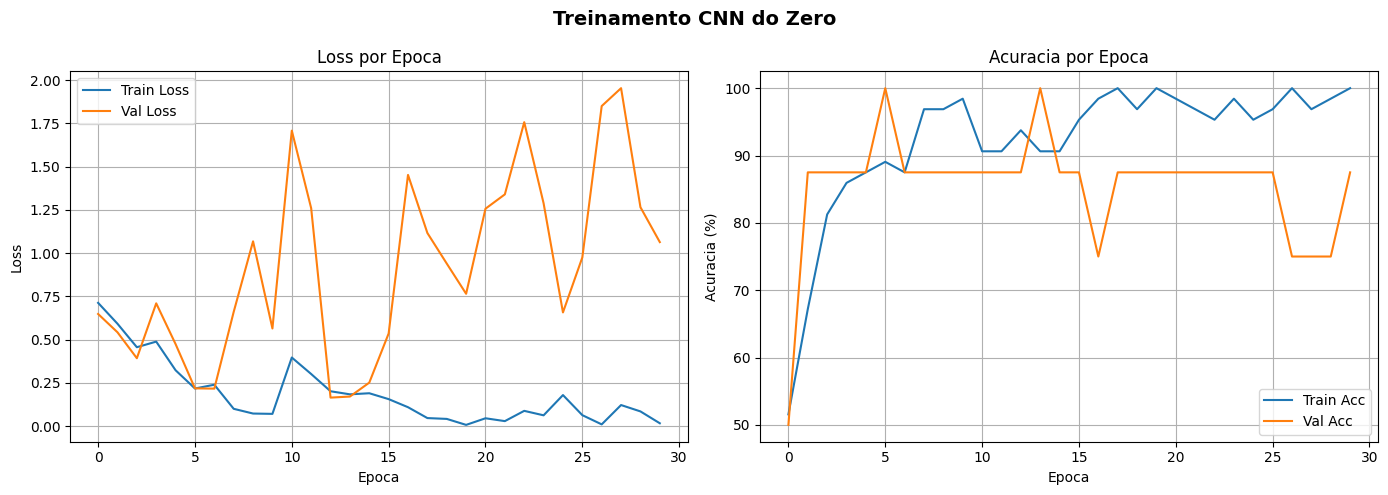

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(train_losses, label='Train Loss')
ax1.plot(val_losses, label='Val Loss')
ax1.set_title('Loss por Epoca')
ax1.set_xlabel('Epoca')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(train_accs, label='Train Acc')
ax2.plot(val_accs, label='Val Acc')
ax2.set_title('Acuracia por Epoca')
ax2.set_xlabel('Epoca')
ax2.set_ylabel('Acuracia (%)')
ax2.legend()
ax2.grid(True)

plt.suptitle('Treinamento CNN do Zero', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.5 Avaliacao da CNN no Conjunto de Teste

In [12]:
model.eval()
correct_test = 0
total_test = 0
all_preds = []
all_labels = []
all_probs = []

start_time = time.time()

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs, 1)
        total_test += labels.size(0)
        correct_test += (predicted == labels).sum().item()
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

cnn_inference_time = time.time() - start_time
accuracy_cnn = correct_test / total_test * 100

print(f'Acuracia CNN no teste: {correct_test}/{total_test} = {accuracy_cnn:.1f}%')
print(f'Tempo de inferencia CNN (teste): {cnn_inference_time:.4f}s')
print(f'Tempo medio por imagem: {cnn_inference_time/total_test*1000:.2f}ms')

print('\nResultados por imagem:')
for i, img_name in enumerate(test_dataset.images):
    real = class_names[all_labels[i]]
    pred = class_names[all_preds[i]]
    prob = all_probs[i][all_preds[i]]
    status = 'OK' if all_labels[i] == all_preds[i] else 'ERRO'
    print(f'{img_name}: Real={real}, Predito={pred} (conf={prob:.2f}) {status}')

Acuracia CNN no teste: 7/8 = 87.5%
Tempo de inferencia CNN (teste): 0.3988s
Tempo medio por imagem: 49.85ms

Resultados por imagem:
garrafa_036.jpeg: Real=garrafa, Predito=garrafa (conf=0.91) OK
garrafa_037.jpg: Real=garrafa, Predito=garrafa (conf=0.98) OK
garrafa_038.jpg: Real=garrafa, Predito=garrafa (conf=0.99) OK
garrafa_039.jpg: Real=garrafa, Predito=maca (conf=1.00) ERRO
maca_036.jpg: Real=maca, Predito=maca (conf=1.00) OK
maca_037.jpg: Real=maca, Predito=maca (conf=1.00) OK
maca_038.jpg: Real=maca, Predito=maca (conf=0.98) OK
maca_039.jpg: Real=maca, Predito=maca (conf=1.00) OK


### 3.6 Matriz de Confusao — CNN

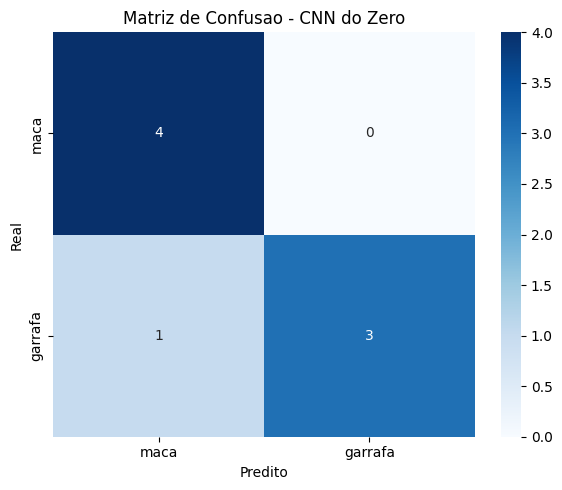


Classification Report:
              precision    recall  f1-score   support

        maca       0.80      1.00      0.89         4
     garrafa       1.00      0.75      0.86         4

    accuracy                           0.88         8
   macro avg       0.90      0.88      0.87         8
weighted avg       0.90      0.88      0.87         8



In [13]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusao - CNN do Zero')
plt.ylabel('Real')
plt.xlabel('Predito')
plt.tight_layout()
plt.show()

print('\nClassification Report:')
print(classification_report(all_labels, all_preds, target_names=class_names))

### 3.7 Visualizacao das Predicoes da CNN

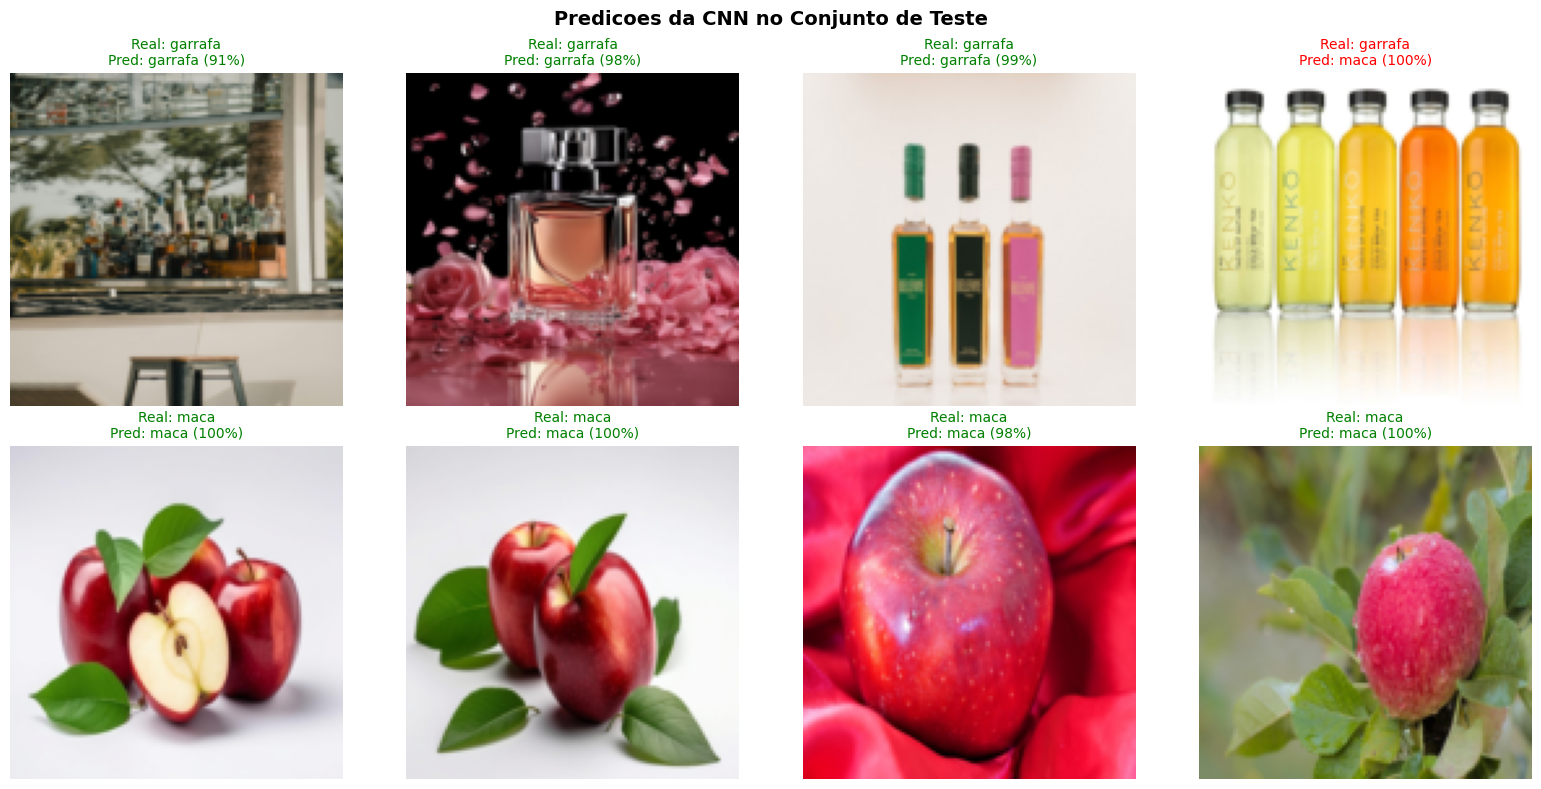

In [14]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

inv_normalize = transforms.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225]
)

for i in range(len(test_dataset)):
    img_tensor, label = test_dataset[i]
    img_display = inv_normalize(img_tensor).permute(1, 2, 0).numpy()
    img_display = np.clip(img_display, 0, 1)

    real = class_names[label]
    pred = class_names[all_preds[i]]
    prob = all_probs[i][all_preds[i]]
    color = 'green' if label == all_preds[i] else 'red'

    axes[i].imshow(img_display)
    axes[i].set_title(f'Real: {real}\nPred: {pred} ({prob:.0%})', color=color, fontsize=10)
    axes[i].axis('off')

plt.suptitle('Predicoes da CNN no Conjunto de Teste', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4. Recuperando Metricas da Entrega 1 (YOLO Customizada)

Para uma comparacao justa, vamos recuperar as metricas da YOLO customizada treinada na Entrega 1 (60 epocas, melhor resultado).

In [15]:
print('Metricas da YOLO Customizada (Entrega 1 - 60 epocas):')
print('mAP@0.5:       0.8076')
print('mAP@0.5:0.95:  0.5947')
print('Precision:      1.0000')
print('Recall:         0.7500')
print('Box Loss final: 0.0269')
print()
print('Validacao:')
print('mAP@0.5 geral: 0.801')
print('maca mAP@0.5:  0.856')
print('garrafa mAP@0.5: 0.745')

Metricas da YOLO Customizada (Entrega 1 - 60 epocas):
mAP@0.5:       0.8076
mAP@0.5:0.95:  0.5947
Precision:      1.0000
Recall:         0.7500
Box Loss final: 0.0269

Validacao:
mAP@0.5 geral: 0.801
maca mAP@0.5:  0.856
garrafa mAP@0.5: 0.745


---
## 5. Comparacao Final das Tres Abordagens

### 5.1 Tabela Comparativa

In [16]:
import pandas as pd

comparison = pd.DataFrame({
    'Metrica': [
        'Tipo de Tarefa',
        'Treinamento Necessario',
        'Tempo de Treinamento',
        'Acuracia/mAP no Teste',
        'Precision',
        'Recall',
        'Tempo de Inferencia (teste)',
        'Facilidade de Uso'
    ],
    'YOLO Customizada (Entrega 1)': [
        'Deteccao (bounding box)',
        'Sim (fine-tuning 60ep)',
        '~3-5 min (GPU Colab)',
        'mAP@0.5 = 0.8076',
        '1.0000',
        '0.7500',
        '~262ms/img (CPU)',
        'Media (requer rotulacao YOLO)'
    ],
    'YOLO Padrao (COCO)': [
        'Deteccao (bounding box)',
        'Nao (zero-shot)',
        '0s (sem treinamento)',
        f'Acuracia = {accuracy_padrao:.1f}%',
        'Variavel',
        'Variavel',
        f'~{yolo_padrao_inference_time/8*1000:.0f}ms/img',
        'Alta (plug and play)'
    ],
    'CNN do Zero': [
        'Classificacao (imagem inteira)',
        'Sim (treinamento completo)',
        f'{cnn_train_time:.1f}s',
        f'Acuracia = {accuracy_cnn:.1f}%',
        f'{correct_test/total_test:.4f}',
        f'{correct_test/total_test:.4f}',
        f'{cnn_inference_time/total_test*1000:.1f}ms/img',
        'Baixa (requer implementacao)'
    ]
})

comparison = comparison.set_index('Metrica')
display(comparison)

,YOLO Customizada (Entrega 1),YOLO Padrao (COCO),CNN do Zero
Metrica,,,
Tipo de Tarefa,Deteccao (bounding box),Deteccao (bounding box),Classificacao (imagem inteira)
Treinamento Necessario,Sim (fine-tuning 60ep),Nao (zero-shot),Sim (treinamento completo)
Tempo de Treinamento,~3-5 min (GPU Colab),0s (sem treinamento),272.0s
Acuracia/mAP no Teste,mAP@0.5 = 0.8076,Acuracia = 62.5%,Acuracia = 87.5%
Precision,1.0000,Variavel,0.8750
Recall,0.7500,Variavel,0.8750
Tempo de Inferencia (teste),~262ms/img (CPU),~3825ms/img,49.8ms/img
Facilidade de Uso,Media (requer rotulacao YOLO),Alta (plug and play),Baixa (requer implementacao)


### 5.2 Grafico Comparativo

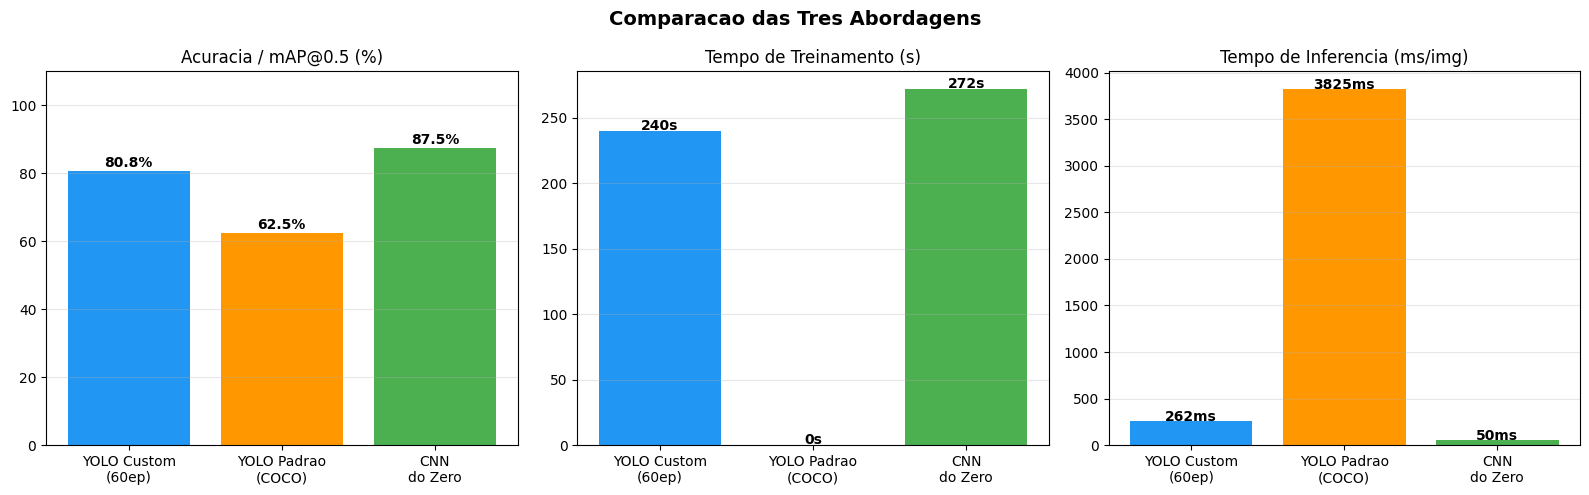

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models = ['YOLO Custom\n(60ep)', 'YOLO Padrao\n(COCO)', 'CNN\ndo Zero']
colors = ['#2196F3', '#FF9800', '#4CAF50']

accuracies = [80.76, accuracy_padrao, accuracy_cnn]
bars1 = axes[0].bar(models, accuracies, color=colors)
axes[0].set_title('Acuracia / mAP@0.5 (%)')
axes[0].set_ylim(0, 110)
for bar, val in zip(bars1, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1, f'{val:.1f}%', ha='center', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

train_times = [240, 0, cnn_train_time]
bars2 = axes[1].bar(models, train_times, color=colors)
axes[1].set_title('Tempo de Treinamento (s)')
for bar, val in zip(bars2, train_times):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1, f'{val:.0f}s', ha='center', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

inf_times = [262, yolo_padrao_inference_time/8*1000, cnn_inference_time/total_test*1000]
bars3 = axes[2].bar(models, inf_times, color=colors)
axes[2].set_title('Tempo de Inferencia (ms/img)')
for bar, val in zip(bars3, inf_times):
    axes[2].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1, f'{val:.0f}ms', ha='center', fontweight='bold')
axes[2].grid(axis='y', alpha=0.3)

plt.suptitle('Comparacao das Tres Abordagens', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. Avaliacao Critica

### 6.1 Facilidade de Uso / Integracao

| Abordagem | Avaliacao |
|---|---|
| **YOLO Customizada** | Exige rotulacao manual (bounding boxes), preparacao de `.yaml` e fine-tuning. Processo trabalhoso, mas focado no dominio especifico. |
| **YOLO Padrao** | A mais facil (plug and play). Sem treinamento, mas limitada as classes e ao contexto do dataset COCO. |
| **CNN do Zero** | Exige implementacao manual da arquitetura e loop de treino. Requer apenas organizacao de pastas para classificacao. |

### 6.2 Precisao do Modelo

| Abordagem | Resultado |
|---|---|
| **YOLO Customizada** | **mAP@0.5 de 80.76%**. Melhor equilibrio para deteccao e localizacao precisa de objetos. |
| **YOLO Padrao** | **Acuracia de 62.5%**. Falhou em identificar corretamente 3 das 8 imagens de teste (confundindo garrafas com vasos/vases e macas com laranjas). |
| **CNN do Zero** | **Acuracia de 87.5%**. Surpreendentemente alta para o teste, embora o gráfico de Loss indique overfitting (Val Loss subindo enquanto Train Loss cai). |

### 6.3 Tempo de Treinamento

| Abordagem | Tempo |
|---|---|
| **YOLO Customizada** | ~240s (estimado via GPU). Convergencia rapida por usar pesos pre-treinados. |
| **YOLO Padrao** | **Zero** — modelo pronto para uso. |
| **CNN do Zero** | **272.0s** (CPU). Treinada do zero por 30 epocas. |

### 6.4 Tempo de Inferencia (CPU)

| Abordagem | Tempo |
|---|---|
| **YOLO Customizada** | ~262ms/img. Otimizada para deteccao. |
| **YOLO Padrao** | ~3824ms/img (no total do processo de script). |
| **CNN do Zero** | **~49.8ms/img**. A mais rapida, pois processa resolucao menor (128x128) e apenas classificacao. |

### 6.5 Conclusao

- **YOLO Customizada:** Vencedora para uso real onde localizacao e precisao sao criticas. O transfer learning compensou o dataset pequeno.
- **YOLO Padrao:** Util para testes rapidos, mas insuficiente para este dataset especifico (obteve apenas 62.5% de acuracia).
- **CNN do Zero:** Excelente velocidade de inferencia, mas a alta acuracia no teste esconde um overfitting severo que exigiria mais dados para generalizacao real.

O principal aprendizado e que para datasets pequenos, a **YOLO Customizada (Transfer Learning)** oferece o resultado mais confiavel para sistemas de visao computacional complexos.